In [1]:
import os
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import numpy as np

import datetime

from numpy.random import choice

from doodl import *

import logging
logger = logging.getLogger()
logger.setLevel(logging.WARNING)
logging.debug("test")

/home/flann/.local/lib/python3.7/site-packages/pandas/core/ops/__init__.py:1115: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  result = method(y)


### Load data

In [2]:
data = load_data()

In [3]:
aisles = get_aisles()
aisles

['fruit', 'spices', 'dairy', 'drinks', 'checkout']

In [4]:
df_location_by_time = get_customer_locations_by_time(data)

In [5]:
transition_matrix = get_trans_matrix(df_location_by_time)
transition_matrix

next aisle,fruit,spices,dairy,drinks,checkout
start aisle,,,,,
fruit,0.608945,0.049235,0.093196,0.053287,0.195336
spices,0.087202,0.427459,0.185247,0.156384,0.143708
dairy,0.047794,0.049250,0.748355,0.056155,0.098446
drinks,0.086873,0.085958,0.010770,0.603434,0.212965
checkout,0.000000,0.000000,0.000000,0.000000,1.000000


In [6]:
initial_choice_proba = get_first_aisle_pmf(df_location_by_time, day='all')
initial_choice_proba

fruit       0.377435
spices      0.181464
dairy       0.287576
drinks      0.153526
checkout    0.000000
Name: all days, dtype: float64

In [7]:
logger.setLevel(logging.WARNING)

In [8]:
doodl = SuperMarket(aisles=aisles, n_checkouts=3, exit_state="checkout")

In [9]:
date = pd.to_datetime("2020-02-27")
%time records_df = doodl.day_in_the_life(date)

CPU times: user 28.8 s, sys: 2.52 ms, total: 28.8 s
Wall time: 28.8 s


In [10]:
records_df

,customer_no,location,timestamp,datetime
0,0,drinks,09:00:00,2020-02-27 09:00:00
1,1,dairy,09:00:00,2020-02-27 09:00:00
2,0,checkout,09:01:00,2020-02-27 09:01:00
3,1,dairy,09:01:00,2020-02-27 09:01:00
4,2,fruit,09:01:00,2020-02-27 09:01:00
...,...,...,...,...
65740,957,drinks,17:00:00,2020-02-27 17:00:00
65741,958,checkout,17:00:00,2020-02-27 17:00:00
65742,959,dairy,17:00:00,2020-02-27 17:00:00
65743,960,drinks,17:00:00,2020-02-27 17:00:00


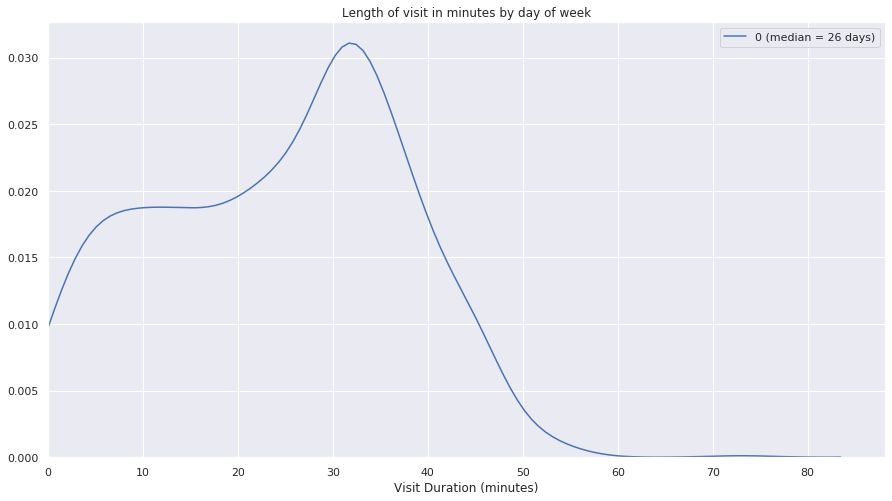

In [11]:
plot_data = records_df.copy()
plot_data['day'] = data['timestamp'].dt.day_name()
plot_data['time_window'] = data['timestamp'].dt.floor('60T').dt.time
entry = plot_data.groupby(['customer_no','day'])['timestamp'].min()
exit = plot_data.groupby(['customer_no','day'])['timestamp'].max()
time_spent = exit - entry
duration = time_spent.rename('Visit Duration (minutes)').dt.seconds/60
plot_data = duration.reset_index() #.rename(columns={'timestamp':'duration'})

fig, ax = plt.subplots(figsize=(15,8))
# for day in ['Monday','Tuesday','Wednesday','Thursday','Friday']:
#     df = plot_data[plot_data['day']==day]
day = 0
df = plot_data
label = "{} (median = {:.0f} days)".format(day, df['Visit Duration (minutes)'].median())
sns.distplot(a=df['Visit Duration (minutes)'], ax=ax, label=label, 
             hist=False,
#                 clip=(0,60),
#                  kde=False,
            );
ax.legend();
title = "Length of visit in minutes by day of week"
ax.set_title(title);
ax.set_xlim(0,None);

# median_table = plot_data.groupby('day')['Visit Duration (minutes)'].median().rename('Median duration')
# median_table = median_table.loc[['Monday','Tuesday','Wednesday','Thursday','Friday']]
# table = ax.table(cellText = median_table.values.reshape(-1,1),
#                  rowLabels=median_table.index, colWidths=[0.1],
#                  loc="right", #bbox=
#                  );



In [12]:
time_range = pd.timedelta_range('00S', '3600S', freq='60S')
customer_logs = pd.DataFrame()

# loop through times
for t in time_range:
    
#     at each time introduce a randomly chosen number of customers
    n = np.random.normal(2.8, 0.4, size=1).round().astype(int)
    
    # generate customers and add to container
    
    # get locations of customers and add to dataframe
    
    # remove any customers that have reached the checkout
    
    

In [13]:
df = records_df.groupby(['timestamp', "location"])['customer_no'].count().unstack(-1).fillna(0)
df

location,checkout,dairy,drinks,fruit,spices
timestamp,,,,,
09:00:00,0.0,1.0,1.0,0.0,0.0
09:01:00,1.0,1.0,0.0,1.0,1.0
09:02:00,1.0,1.0,2.0,0.0,1.0
09:03:00,0.0,1.0,2.0,2.0,1.0
09:04:00,1.0,3.0,1.0,3.0,0.0
...,...,...,...,...,...
16:56:00,218.0,6.0,1.0,5.0,3.0
16:57:00,218.0,8.0,2.0,3.0,3.0
16:58:00,219.0,8.0,3.0,3.0,2.0


In [16]:
from imageio import imread, imwrite
from scipy.ndimage import rotate
from PIL import Image
import numpy as np
import cv2

In [100]:
img = cv2.imread('market.png')
heigth, width = img.shape[:2]


aisle_colour = [200,0,200]
checkout_colour = [255, 0, 0]
square_side = 20

# parameters for customer icons in aisles
n_cols = 2
n_rows = 10
row_divide = 20
col_divide = 20
col_top = 150
offset = 80

aisles = ['drinks', 'dairy', 'spices', 'fruit']
aisles_dict = {}
for i,a in enumerate(aisles):
    aisles_dict[a] = {}
    for row in range(n_rows):
        for col in range(n_cols):
            aisles_dict[a][f"ul_r{row}c{col}"] = [
                col_top + (square_side + row_divide) * row,
                offset + int(width/4) * i + (square_side + col_divide) * col
            ]

# parameters for customer icons in checkouts
n_cols = 2
n_rows = 100
row_divide = 7
col_divide = 7
col_bot = 600
offset = 80
section_width = 560

checkout_dict = {}
for i in range(4):
    checkout_dict[i] = {}
    for row in range(n_rows):
        for col in range(n_cols):
            checkout_dict[i][f"ll_r{row}c{col}"] = [
                col_bot - (square_side + row_divide) * row,
                offset + int(section_width/4) * i + (square_side + col_divide) * col
            ]

img_with_blocks = img.copy()

# for a, coords in aisles_dict.items():
#     for name, ul in coords.items():
#         y, x = ul
#         img_with_blocks[y:y+square_side, x:x+square_side] = aisle_colour

# for i, coords in checkout_dict.items():
#     for name, ll in coords.items():
#         y, x = ll
#         img_with_blocks[y-square_side:y, x:x+square_side] = checkout_colour


# Image.fromarray(img_with_blocks)

img = cv2.imread('market.png')

df = records_df.groupby(['timestamp', "location"])['customer_no'].count().unstack(-1).fillna(0).astype(int)

# arguments for cv2 text
org = (80,100)
font = cv2.FONT_HERSHEY_SIMPLEX 
fontScale = 1 
text_colour = (0, 0, 0) 
thickness = 2

# while True:
for time, data in df.iterrows():
    frame = img.copy()

    for a, coords in aisles_dict.items():
        for i, ul in enumerate(coords.values()):
            y, x = ul
            frame[y:y+square_side, x:x+square_side] = aisle_colour
            if i >= df.loc[time, a]:
                break
                
    for coords in checkout_dict.values():
        for i, ll in enumerate(coords.values()):
            y, x = ll
            frame[y-square_side:y, x:x+square_side] = checkout_colour
            if i >= df.loc[time, "checkout"]:
                break
    
    ss = time.seconds
    time_string = "Time: {:02d}:{:02d}".format(ss//3600,(ss-(ss//3600)*3600)//60)
    frame = cv2.putText(frame, time_string, org, font,  
                   fontScale, text_colour, thickness, cv2.LINE_AA) 
    
#     print(time_string)
    cv2.imshow('frame', frame)

    if cv2.waitKey(100) & 0xFF == ord('q'):
        break
    
#     if cv2.waitKey(100) & 0xFF == ord('q'):
#         break


cv2.destroyAllWindows()